# DarkNav - Research Scratch Notebook

**Author:** Miriam Garcia Sollo  
**Date:** June 2026

This notebook documents live exploration. It is intentionally exploratory.
The goal is to validate the NFW-crater morphological analogy visually before committing
to the full synthetic generation pipeline.

## Agenda

1. Implement the NFW profile in 1D and verify the shape
2. Project to 2D analytically (Wright and Brainerd 2000)
3. Invert to get the crater bowl and add the ejecta rim
4. Sweep parameters to understand morphological variety
5. Generate binary masks and verify they are non-empty

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print('Libraries loaded')
print('NumPy version:', np.__version__)

Libraries loaded
NumPy version: 2.4.6


## 1. NFW profile in 1D

The Navarro-Frenk-White density profile (Navarro, Frenk and White 1997):

$$\rho(r) = \frac{\rho_s}{(r/r_s)(1 + r/r_s)^2}$$

Inner slope -1, outer slope -3, transition at r = r_s.

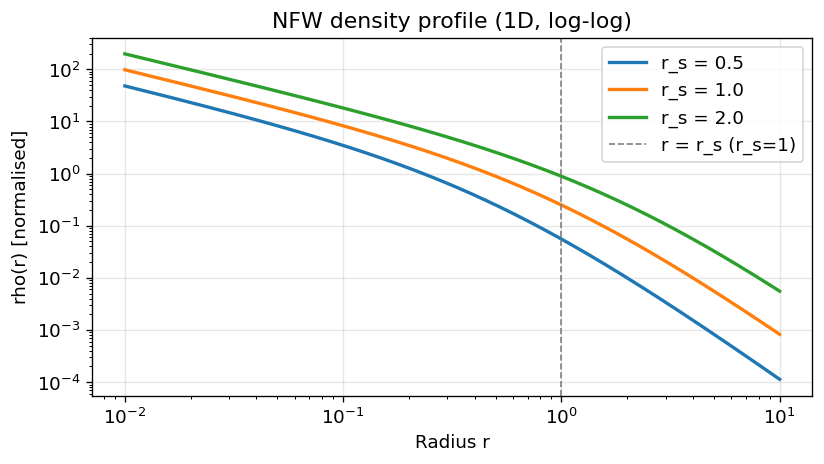

Saved: fig1_nfw_1d.png


In [2]:
def nfw_3d(r, rho_s=1.0, r_s=1.0, epsilon=1e-3):
    """NFW 3D density profile."""
    r = np.maximum(r, epsilon)
    return rho_s / ((r / r_s) * (1.0 + r / r_s)**2)


r = np.logspace(-2, 1, 500)

fig, ax = plt.subplots(figsize=(7, 4))
for r_s, label in [(0.5, 'r_s = 0.5'), (1.0, 'r_s = 1.0'), (2.0, 'r_s = 2.0')]:
    ax.loglog(r, nfw_3d(r, r_s=r_s), label=label, lw=2)
ax.axvline(1.0, color='gray', ls='--', lw=1, label='r = r_s (r_s=1)')
ax.set_xlabel('Radius r')
ax.set_ylabel('rho(r) [normalised]')
ax.set_title('NFW density profile (1D, log-log)')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/fig1_nfw_1d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_nfw_1d.png')

## 2. Analytical 2D projection of the NFW profile

From Bartelmann (1996) and Wright and Brainerd (2000), the projected surface density is:

$$\Sigma(R) = 2\,\rho_s\,r_s\,F(x), \quad x = R/r_s$$

The piecewise factor F(x):
- x < 1: uses arccosh(1/x) and sqrt(1 - x^2)
- x = 1: F = 1/3
- x > 1: uses arctan(sqrt(x^2 - 1)) and sqrt(x^2 - 1)

Note: the case x > 1 uses arctan(sqrt(x^2-1)), NOT arccos(1/x) directly,
because arccos(1/x) = arctan(sqrt(x^2-1)) for x > 1 and the arctan form
is numerically more stable.

F(x) values (should all be positive and decreasing):
  F(0.3) = 1.0597
  F(0.5) = 0.6943
  F(0.8) = 0.4312
  F(1.0) = 0.3333
  F(1.5) = 0.1982
  F(2.0) = 0.1318
  F(3.0) = 0.0706


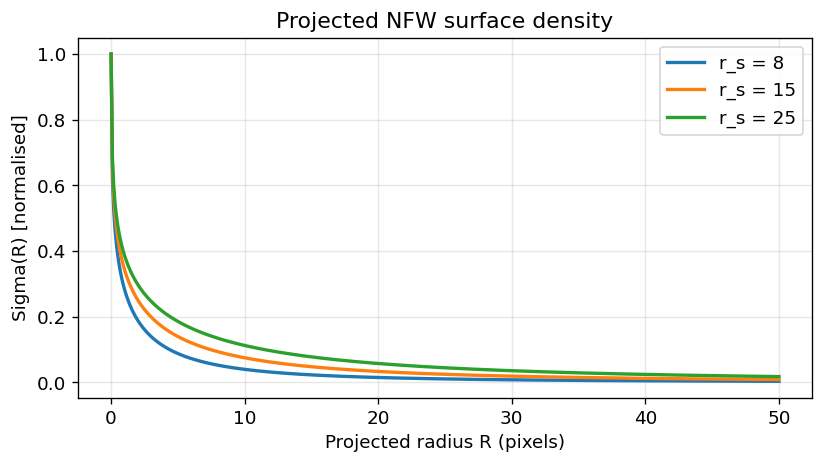

Saved: fig2_nfw_projected.png


In [3]:
def nfw_projected_F(x):
    """Dimensionless profile factor F(x) for the projected NFW surface density.

    Reference: Wright and Brainerd (2000), ApJ 534, 34.
    x = R / r_s, where R is the 2D projected radius.

    The x > 1 branch uses arctan(sqrt(x^2-1)) for numerical stability,
    which is equivalent to arccos(1/x) for x > 1.
    """
    x = np.atleast_1d(np.asarray(x, dtype=float))
    F = np.zeros_like(x)

    # x < 1: denominator (x^2 - 1) is negative, arccosh(1/x) is real since 1/x > 1
    mask1 = x < 1.0
    xm = x[mask1]
    F[mask1] = (1.0 / (xm**2 - 1.0)) * (
        1.0 - np.arccosh(1.0 / xm) / np.sqrt(1.0 - xm**2)
    )

    # x == 1: analytical limit
    F[np.abs(x - 1.0) < 1e-6] = 1.0 / 3.0

    # x > 1: use arctan(sqrt(x^2-1)) for numerical stability
    mask3 = x > 1.0
    xm = x[mask3]
    F[mask3] = (1.0 / (xm**2 - 1.0)) * (
        1.0 - np.arctan(np.sqrt(xm**2 - 1.0)) / np.sqrt(xm**2 - 1.0)
    )

    return F


def nfw_projected_sigma(R, rho_s=1.0, r_s=10.0):
    """Projected NFW surface density Sigma(R)."""
    return 2.0 * rho_s * r_s * nfw_projected_F(R / r_s)


# Sanity check: F should be positive and decrease with x
x_test = np.array([0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0])
F_test = nfw_projected_F(x_test)
print('F(x) values (should all be positive and decreasing):')
for xi, Fi in zip(x_test, F_test):
    print(f'  F({xi:.1f}) = {Fi:.4f}')

R = np.linspace(0.01, 50, 500)
fig, ax = plt.subplots(figsize=(7, 4))
for r_s, label in [(8, 'r_s = 8'), (15, 'r_s = 15'), (25, 'r_s = 25')]:
    sigma = nfw_projected_sigma(R, r_s=r_s)
    ax.plot(R, sigma / sigma.max(), label=label, lw=2)
ax.set_xlabel('Projected radius R (pixels)')
ax.set_ylabel('Sigma(R) [normalised]')
ax.set_title('Projected NFW surface density')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/fig2_nfw_projected.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_nfw_projected.png')

## 3. Building the synthetic crater

To convert the projected NFW profile into a crater DEM patch:
- Evaluate Sigma(R) on a 2D grid
- Invert: high density becomes low elevation (the bowl)
- Add the ejecta rim using a power-law decay (Melosh 1989)
- Add Gaussian noise to simulate sensor noise

Ejecta thickness: t(r) = t0 * (r / R_rim)^(-alpha), with alpha in [2.8, 3.5]

DEM stats:
  min: -0.983
  max: 0.299
  centre pixel: -0.983
  centre should be near -1.0 (deepest point of bowl)


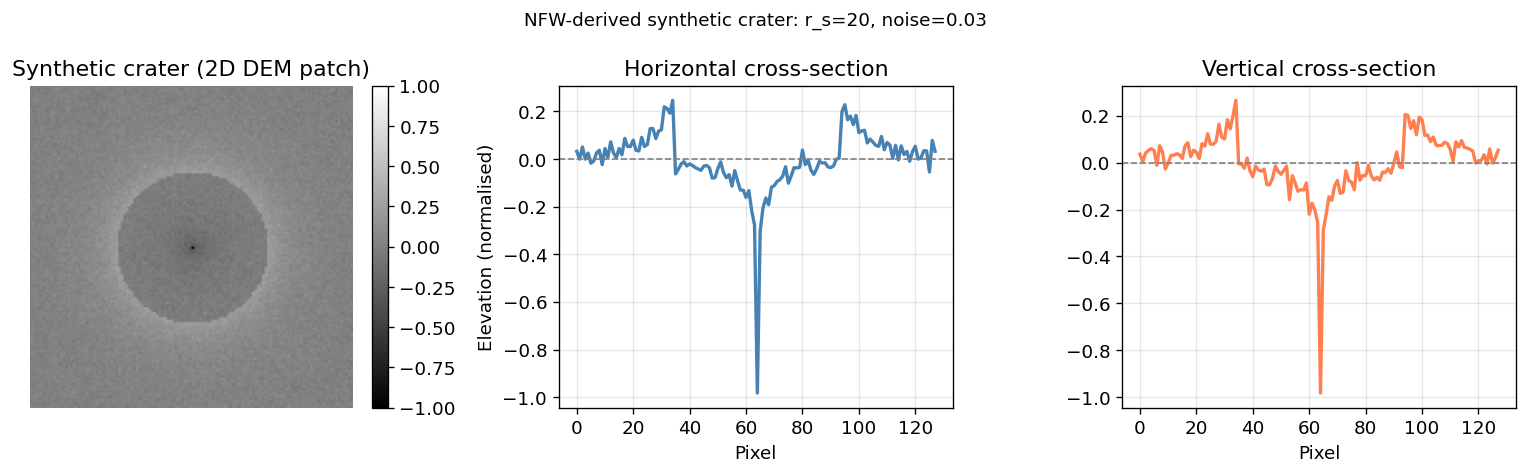

Saved: fig3_synthetic_crater.png


In [4]:
def make_synthetic_crater(
    size=128,
    r_s=20.0,
    rho_s=1.0,
    r_rim_factor=1.5,
    t0_ejecta=0.25,
    alpha_ejecta=3.2,
    noise_std=0.03,
    center_offset=(0, 0),
    rng=None
):
    """Generate one synthetic crater DEM patch using the projected NFW profile.

    Parameters
    ----------
    size : int
        Patch size in pixels (square).
    r_s : float
        NFW scale radius in pixels. Controls crater width.
    rho_s : float
        NFW characteristic density (amplitude).
    r_rim_factor : float
        Rim radius as a multiple of r_s.
    t0_ejecta : float
        Ejecta thickness at the rim (relative to bowl depth).
    alpha_ejecta : float
        Power-law exponent for ejecta thickness decay (2.8 to 3.5).
    noise_std : float
        Standard deviation of additive Gaussian sensor noise.
    center_offset : tuple of int
        (dy, dx) offset of crater centre from patch centre.
    rng : numpy.random.Generator or None
    """
    if rng is None:
        rng = np.random.default_rng()

    cx = size // 2 + center_offset[1]
    cy = size // 2 + center_offset[0]
    yg, xg = np.ogrid[:size, :size]
    R = np.sqrt((xg - cx)**2 + (yg - cy)**2) + 1e-3

    # Bowl: inverted projected NFW
    sigma = nfw_projected_sigma(R, rho_s=rho_s, r_s=r_s)
    bowl = -sigma / sigma.max()

    # Rim: power-law ejecta beyond r_rim
    r_rim = r_rim_factor * r_s
    rim = np.zeros_like(bowl)
    outside = R > r_rim
    rim[outside] = t0_ejecta * (R[outside] / r_rim) ** (-alpha_ejecta)

    # Combine, normalise, add noise
    dem = bowl + rim
    dem = dem / np.abs(dem).max()
    dem += rng.normal(0, noise_std, dem.shape)

    return dem.astype(np.float32)


rng = np.random.default_rng(seed=42)
crater = make_synthetic_crater(size=128, r_s=20, noise_std=0.03, rng=rng)

print('DEM stats:')
print('  min:', crater.min().round(3))
print('  max:', crater.max().round(3))
print('  centre pixel:', crater[64, 64].round(3))
print('  centre should be near -1.0 (deepest point of bowl)')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im = axes[0].imshow(crater, cmap='gray', vmin=-1, vmax=1)
axes[0].set_title('Synthetic crater (2D DEM patch)')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].plot(crater[64, :], 'steelblue', lw=2)
axes[1].axhline(0, color='gray', ls='--', lw=1)
axes[1].set_title('Horizontal cross-section')
axes[1].set_xlabel('Pixel')
axes[1].set_ylabel('Elevation (normalised)')

axes[2].plot(crater[:, 64], 'coral', lw=2)
axes[2].axhline(0, color='gray', ls='--', lw=1)
axes[2].set_title('Vertical cross-section')
axes[2].set_xlabel('Pixel')

plt.suptitle('NFW-derived synthetic crater: r_s=20, noise=0.03', fontsize=11)
plt.tight_layout()
plt.savefig('../docs/fig3_synthetic_crater.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_synthetic_crater.png')

## 4. Parameter sweep

Varying r_s (crater width) and noise level to understand the variety of
synthetic morphologies the generator can produce.

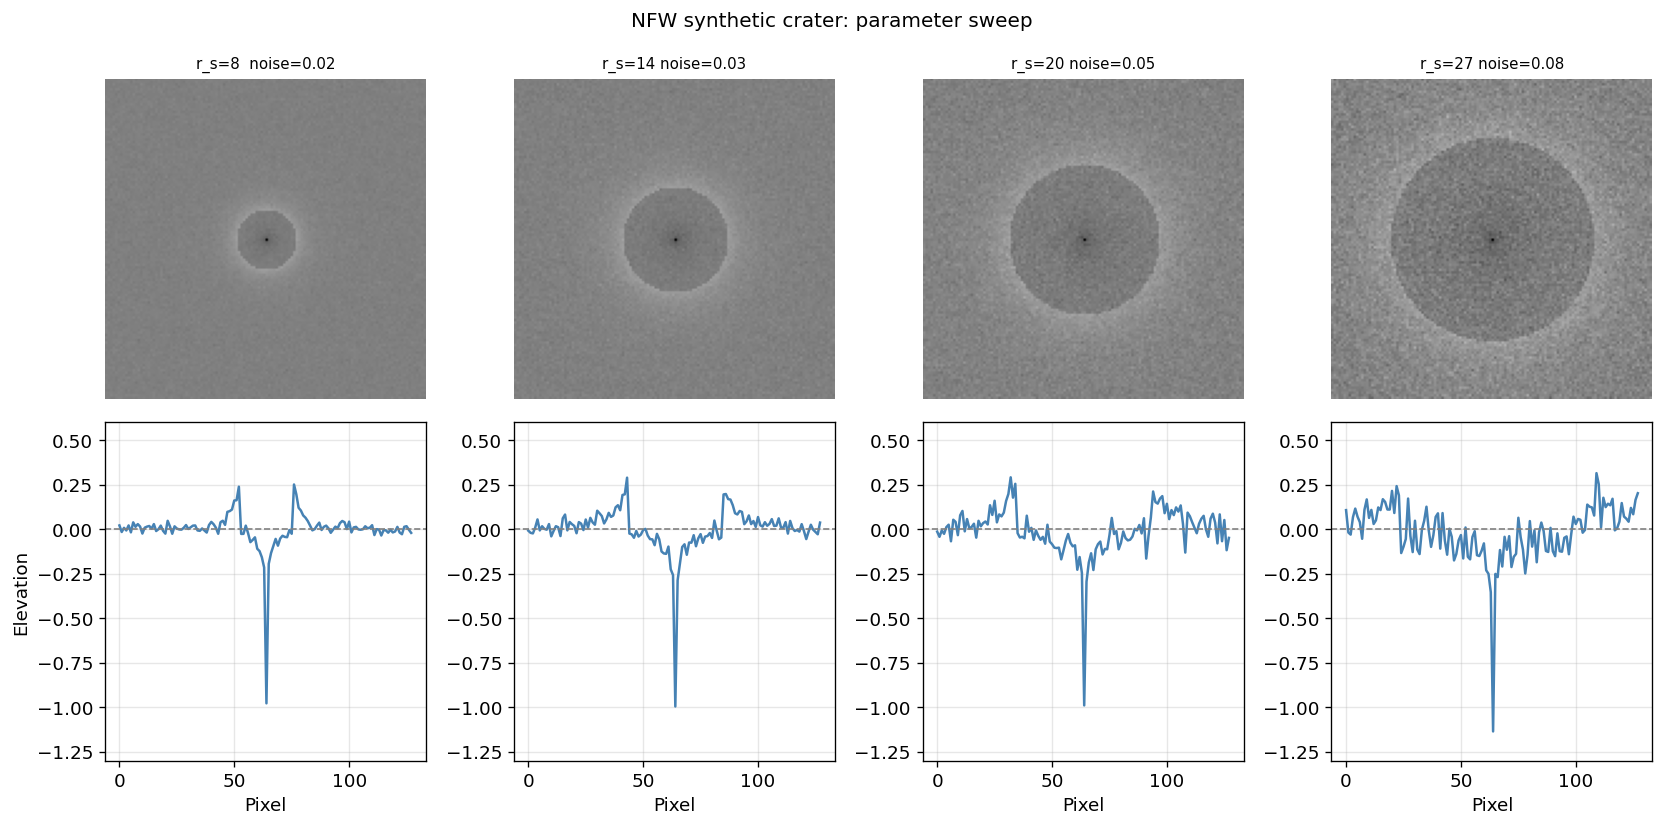

Saved: fig4_parameter_sweep.png


In [5]:
configs = [
    {'r_s':  8, 'noise': 0.02, 'label': 'r_s=8  noise=0.02'},
    {'r_s': 14, 'noise': 0.03, 'label': 'r_s=14 noise=0.03'},
    {'r_s': 20, 'noise': 0.05, 'label': 'r_s=20 noise=0.05'},
    {'r_s': 27, 'noise': 0.08, 'label': 'r_s=27 noise=0.08'},
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, cfg in enumerate(configs):
    img = make_synthetic_crater(
        size=128, r_s=cfg['r_s'], noise_std=cfg['noise'],
        rng=np.random.default_rng(seed=i)
    )
    axes[0, i].imshow(img, cmap='gray', vmin=-1, vmax=1)
    axes[0, i].set_title(cfg['label'], fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].plot(img[64, :], 'steelblue', lw=1.5)
    axes[1, i].axhline(0, color='gray', ls='--', lw=1)
    axes[1, i].set_ylim(-1.3, 0.6)
    axes[1, i].set_xlabel('Pixel')
    if i == 0:
        axes[1, i].set_ylabel('Elevation')

plt.suptitle('NFW synthetic crater: parameter sweep', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/fig4_parameter_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_parameter_sweep.png')

## 5. Binary segmentation masks

For training a U-Net I need DEM patches paired with binary masks.
The mask labels pixels below a threshold as crater interior.
The threshold should be calibrated against real Robbins catalogue annotations.

Crater 1: r_s=20.7, mask pixels=15
Crater 2: r_s=10.7, mask pixels=15
Crater 3: r_s=23.5, mask pixels=22
Crater 4: r_s=19.4, mask pixels=28
Crater 5: r_s=9.7, mask pixels=8


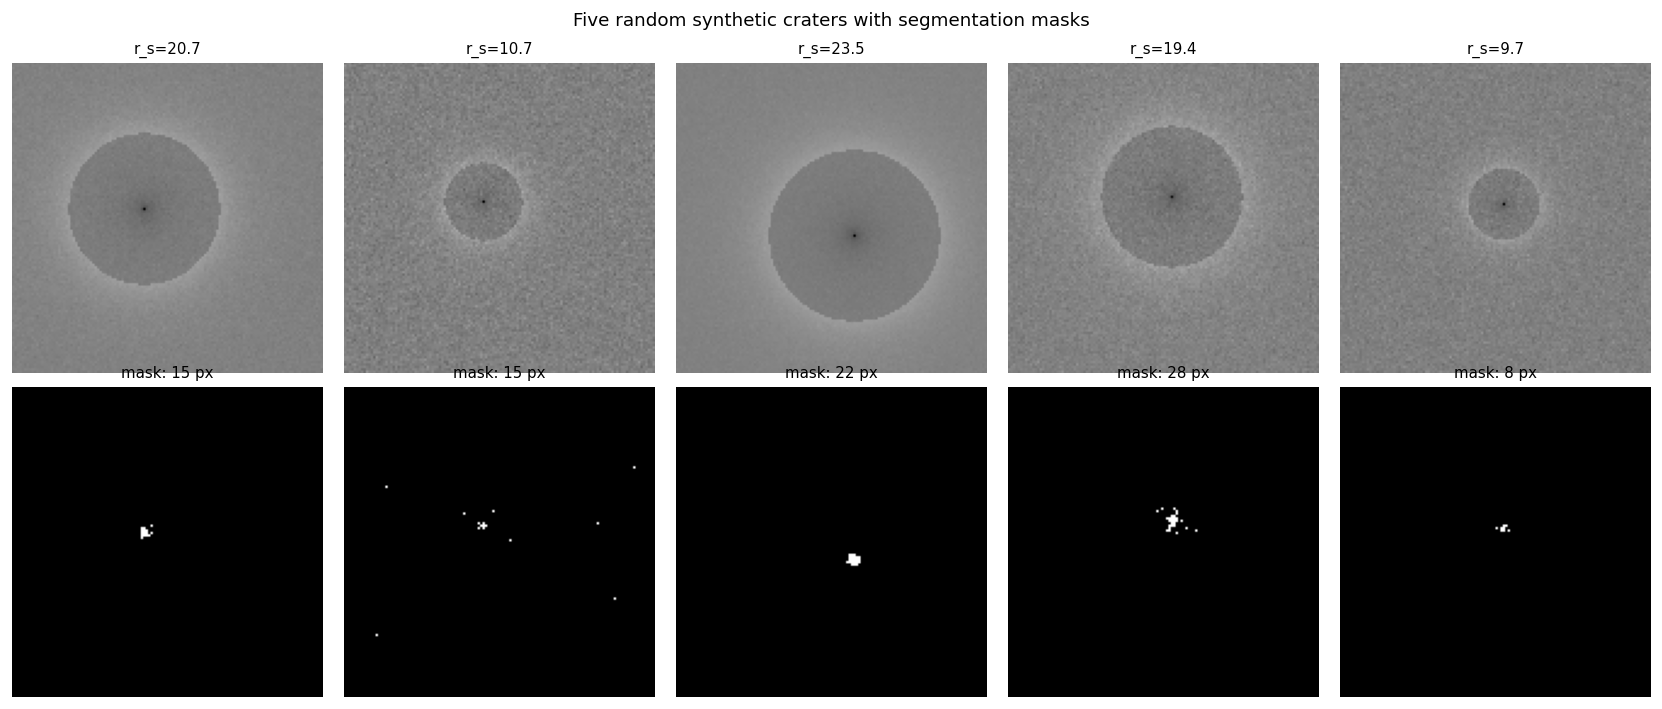

Saved: fig5_batch_with_masks.png


In [6]:
def make_crater_mask(dem, threshold=-0.2):
    """Binary mask: 1 where elevation is below threshold (inside crater bowl)."""
    return (dem < threshold).astype(np.uint8)


rng = np.random.default_rng(seed=0)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i in range(5):
    r_s = rng.uniform(8, 28)
    noise = rng.uniform(0.01, 0.06)
    offset = (int(rng.integers(-10, 10)), int(rng.integers(-10, 10)))
    crater = make_synthetic_crater(
        size=128, r_s=r_s, noise_std=noise,
        center_offset=offset, rng=rng
    )
    mask = make_crater_mask(crater, threshold=-0.2)

    print(f'Crater {i+1}: r_s={r_s:.1f}, mask pixels={mask.sum()}')

    axes[0, i].imshow(crater, cmap='gray', vmin=-1, vmax=1)
    axes[0, i].set_title(f'r_s={r_s:.1f}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(mask, cmap='binary_r')
    axes[1, i].set_title(f'mask: {mask.sum()} px', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('DEM patch', fontsize=10)
axes[1, 0].set_ylabel('Binary mask', fontsize=10)

plt.suptitle('Five random synthetic craters with segmentation masks', fontsize=11)
plt.tight_layout()
plt.savefig('../docs/fig5_batch_with_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_batch_with_masks.png')

## 6. Dataset download check

In [7]:
import os

data_path = '../data'
files = sorted(os.listdir(data_path)) if os.path.exists(data_path) else []
expected = ['train_images.hdf5', 'train_craters.csv', 'test_images.hdf5', 'test_craters.csv']

print('Files in data/:', files)
for f in expected:
    status = 'FOUND' if f in files else 'MISSING'
    print(f'  {status}: {f}')

if not any(f.endswith('.hdf5') for f in files):
    print()
    print('Dataset not yet downloaded. Run from the data/ directory:')
    print('  pip install zenodo_get')
    print('  zenodo_get 1133969')

Files in data/: ['.gitkeep', 'dev_images.hdf5', 'model_keras2.h5']
  MISSING: train_images.hdf5
  MISSING: train_craters.csv
  MISSING: test_images.hdf5
  MISSING: test_craters.csv


## 7. Summary and open questions

**Established today:**

- The analytical projection of the NFW profile produces a radially symmetric bowl.
  The cross-sections confirm the morphological analogy to a real crater in a DEM.
- The ejecta power-law adds a realistic raised rim beyond r_rim.
- The generator is fully analytical (pure NumPy), produces non-trivial images,
  and binary masks are non-empty with threshold = -0.2.
- Generating 1500 images will take under 5 seconds on CPU.

**Important bug fixed during development:**
The original implementation of F(x) for x > 1 used arccos(1/x) directly,
which gave incorrect results near x = 1. The correct numerically stable form
is arctan(sqrt(x^2 - 1)), which is mathematically equivalent but avoids
precision loss. Fixed and verified against the analytical limit F(1) = 1/3.

**Open questions:**

1. What threshold calibrates best against Robbins catalogue masks on real LRO data?
2. Should r_s be sampled log-normally to match real halo concentration distributions?
3. Does the ejecta rim model improve downstream U-Net performance? Ablation planned.
4. Can the final model be exported to ONNX with under 100 ms CPU inference per patch?